Epoch 1, Loss: 2.2184, Accuracy: 0.3133
Epoch 2, Loss: 2.0497, Accuracy: 0.4433
Epoch 3, Loss: 1.9058, Accuracy: 0.5733
Epoch 4, Loss: 1.7798, Accuracy: 0.6233
Epoch 5, Loss: 1.6689, Accuracy: 0.6633
Epoch 6, Loss: 1.5712, Accuracy: 0.7000


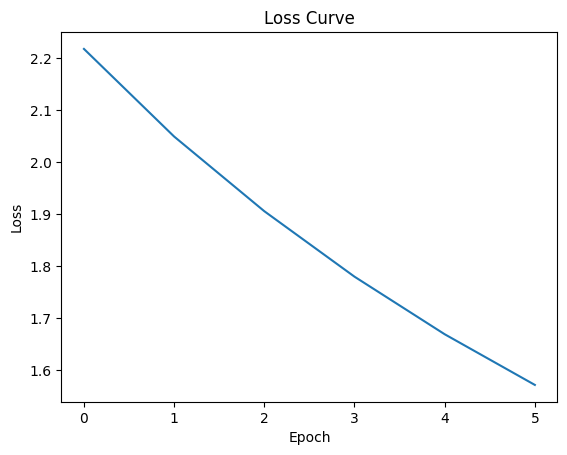

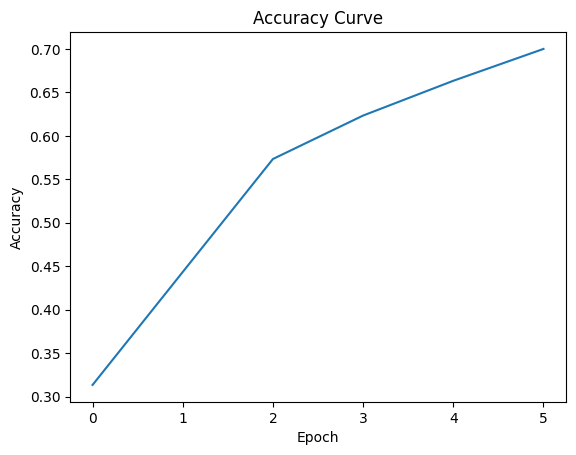

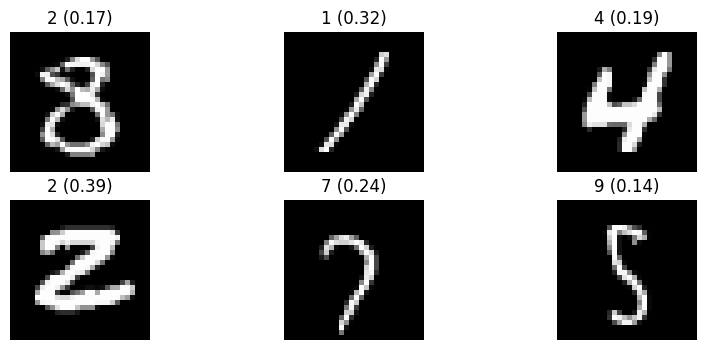

Test Accuracy: 0.66


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

# Load data
(X, y), _ = mnist.load_data()
X = X / 255.0

X = X[:1200]
y = y[:1200]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Parameters (slightly changed)
filters = np.random.randn(3, 3, 3) / 9   # 3 filters now
fc_weights = np.random.randn(13*13*3, 10) / 100
lr = 0.005

# Layers
def convolve(img, filters):
    h, w = img.shape
    out = np.zeros((h-2, w-2, filters.shape[0]))

    for k in range(filters.shape[0]):
        for i in range(h-2):
            for j in range(w-2):
                out[i,j,k] = np.sum(img[i:i+3, j:j+3] * filters[k])
    return out

def relu(x):
    return np.maximum(0, x)

def maxpool(x):
    h,w,d = x.shape
    out = np.zeros((h//2, w//2, d))

    for k in range(d):
        for i in range(0,h,2):
            for j in range(0,w,2):
                out[i//2, j//2, k] = np.max(x[i:i+2, j:j+2, k])
    return out

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

# Training
losses = []
accuracies = []

for epoch in range(6):
    total_loss = 0
    correct = 0

    for i in range(300):
        img = X_train[i]
        label = y_train[i]

        conv = convolve(img, filters)
        rel = relu(conv)
        pool = maxpool(rel)
        flat = pool.flatten()

        logits = np.dot(flat, fc_weights)
        probs = softmax(logits)
        probs = np.clip(probs, 1e-10, 1.0)

        loss = -np.log(probs[label])
        total_loss += loss

        pred = np.argmax(probs)
        if pred == label:
            correct += 1

        # Backprop (FC only)
        dL = probs
        dL[label] -= 1
        fc_weights -= lr * np.outer(flat, dL)

    losses.append(total_loss / 300)
    accuracies.append(correct / 300)

    print(f"Epoch {epoch+1}, Loss: {losses[-1]:.4f}, Accuracy: {accuracies[-1]:.4f}")

plt.figure()
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(accuracies)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(10,4))
for i in range(6):
    img = X_test[i]

    conv = convolve(img, filters)
    rel = relu(conv)
    pool = maxpool(rel)
    flat = pool.flatten()
    logits = np.dot(flat, fc_weights)
    probs = softmax(logits)

    pred = np.argmax(probs)
    confidence = np.max(probs)

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{pred} ({confidence:.2f})")
    plt.axis('off')

plt.show()

# Test accuracy
correct = 0
for i in range(100):
    img = X_test[i]
    conv = convolve(img, filters)
    rel = relu(conv)
    pool = maxpool(rel)
    flat = pool.flatten()
    pred = np.argmax(np.dot(flat, fc_weights))

    if pred == y_test[i]:
        correct += 1

print("Test Accuracy:", correct / 100)